# Rule-Based System

In [1]:
from maverick import Maverick
import spacy
from spacy.tokens import Doc
import sys
from modules.utils.dict_utils import check_dictionary
from nltk.corpus import wordnet as wn
from modules.explicit_cues import fem_lex, masc_lex, neutral_lex, parse_sent, syntactic_indexes, build_token_to_cluster, conj_chain, gender_person_token, update_label_map, update_cluster_gender, attr_matches_head, is_plural, is_gendered, resolve_from_labels, update_label_map, labeled_text, is_person, gender_cluster, find_span
import gender_guesser.detector as gender
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
from modules.evaluation import evaluate_test_set, evaluate_rule_based, run_rule_based, detect_gender_middle, evaluate_rule_llm
from collections import defaultdict

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nlp = spacy.load("en_core_web_md")
d = gender.Detector()

In [3]:
coref_model = Maverick(
  hf_name_or_path = "sapienzanlp/maverick-mes-preco",
  device = "cpu"
)

coref_model.model = coref_model.model.float() 

sapienzanlp/maverick-mes-preco loading


Loading weights: 100%|█████████████████████| 390/390 [00:00<00:00, 12192.11it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archite

In [4]:
def detect_gender(text, target_index=None, model = coref_model):
    """
    detects and labels gender for every person noun in the text.
    coref clusters are used for referential gender enrichment,
    but token selection is independent of coref.
    """

    spacy_doc = parse_sent(text)
    tokens = [token.text for token in spacy_doc]
    entity_dict = model.predict(tokens, singletons=True)

    fem_mod_indexes, masc_mod_indexes, attr_indexes, person_indexes = syntactic_indexes(spacy_doc)

    force_indexes = {target_index} if target_index is not None else set()

    dependent_to_head = {}
    for token in spacy_doc:
        if token.dep_ == 'relcl':
            for child in token.children:
                if child.dep_ == 'attr':
                    dependent_to_head[child.i] = token.head.i
                    for conj in conj_chain(child):
                        dependent_to_head[conj.i] = token.head.i
        if token.dep_ == 'appos':
            dependent_to_head[token.i] = token.head.i
            for conj in conj_chain(token):
                dependent_to_head[conj.i] = token.head.i

    token_to_cluster = build_token_to_cluster(entity_dict, spacy_doc)

    results = []
    label_map = {}
    individual_labels = set()

    for token in spacy_doc:

        if token.i in dependent_to_head and token.i not in force_indexes:
            continue

        is_candidate = (
            (token.pos_ in ('NOUN', 'PROPN') and is_person(token.lemma_))
            or token.i in person_indexes
            or token.i in force_indexes
        )

        if not is_candidate:
            continue

        if token.i in token_to_cluster:
            cluster_words, _ = token_to_cluster[token.i]
        else:
            cluster_words = []

        label = gender_person_token(
            token, cluster_words,
            fem_mod_indexes, masc_mod_indexes,
            person_indexes, spacy_doc,
            force_indexes=force_indexes
        )
        if label is not None:
            update_label_map(label_map, token.i, label, individual_labels)

    seen_clusters = set()

    for cluster_words, cluster_spans in zip(
        entity_dict['clusters_token_text'],
        entity_dict['clusters_token_offsets']
    ):
        cluster_key = tuple(tuple(s) for s in cluster_spans)
        if cluster_key in seen_clusters:
            continue
        seen_clusters.add(cluster_key)

        cluster_result = gender_cluster(
            cluster_words, cluster_spans, spacy_doc,
            fem_mod_indexes, masc_mod_indexes, attr_indexes,
            dependent_to_head, person_indexes
        )

        if cluster_result is None:
            continue

        mentions = []
        for ref in cluster_spans:
            mentions.append(spacy_doc[ref[0]:ref[1]+1].text)
        entity_gender = cluster_result['entity_gender']

        results.append({'mentions': mentions, 'entity_gender': entity_gender})

        for ref in cluster_spans:
            head = spacy_doc[ref[0]:ref[1]+1].root
            if (head.pos_ in ('NOUN', 'PROPN') and is_person(head.lemma_)) or head.i in person_indexes:
                conjuncts = conj_chain(head)
                has_different = False
                for conj in conjuncts:
                    conj_label = gender_person_token(conj, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                    head_label = gender_person_token(head, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                    if conj_label != head_label:
                        has_different = True
                        break
                if len(conjuncts) > 0 and has_different:
                    update_label_map(label_map, head.i, gender_person_token(head, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc), individual_labels)
                    individual_labels.add(head.i)
                else:
                    if is_plural(head):
                        has_ambiguous_subj_conj = False
                        for (attr_i, subj_i, _, __) in attr_indexes:
                            if attr_i != head.i:
                                continue
                            subj_token = spacy_doc[subj_i]
                            for conj in conj_chain(subj_token):
                                conj_label = gender_person_token(conj, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                                if not is_gendered(conj_label):
                                    has_ambiguous_subj_conj = True
                                    break
                            subj_label = gender_person_token(subj_token, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                            if not is_gendered(subj_label):
                                has_ambiguous_subj_conj = True

                        head_label = gender_person_token(head, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                        if has_ambiguous_subj_conj and not is_gendered(head_label):
                            update_label_map(label_map, head.i, 'ambiguous', individual_labels)
                        else:
                            update_label_map(label_map, head.i, entity_gender, individual_labels)
                    else:
                        update_label_map(label_map, head.i, entity_gender, individual_labels)

            for conj in conj_chain(head):
                if (conj.pos_ in ('NOUN', 'PROPN') and is_person(conj.lemma_)) or conj.i in person_indexes:
                    own_label = gender_person_token(conj, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                    head_label = gender_person_token(head, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                    if own_label != head_label:
                        update_label_map(label_map, conj.i, own_label, individual_labels)
                        individual_labels.add(conj.i)
                    else:
                        update_label_map(label_map, conj.i, entity_gender, individual_labels)

    results = update_cluster_gender(results, spacy_doc)

    for entity in results:
        entity_gender = entity['entity_gender']
        for mention in entity['mentions']:
            span = find_span(mention, spacy_doc)
            if span is None:
                continue
            head = span.root
            for (attr_i, subj_i, _, is_partitive) in attr_indexes:
                if not attr_matches_head(subj_i, head, spacy_doc):
                    continue
                attr_token = spacy_doc[attr_i]
                if attr_token.pos_ not in ('NOUN', 'PROPN') or not is_person(attr_token.lemma_) or not attr_token.i:
                    continue

                conj_partners = []
                for (other_attr_i, other_subj_i, _, __) in attr_indexes:
                    if other_attr_i == attr_i:
                        continue
                    if not attr_matches_head(other_subj_i, head, spacy_doc):
                        continue
                    for conj in conj_chain(attr_token):
                        if conj.i == other_attr_i:
                            conj_partners.append(spacy_doc[other_attr_i])

                subj_token = spacy_doc[subj_i]

                for (other_attr_i, other_subj_i, _, __) in attr_indexes:
                    if other_attr_i == subj_token.i:
                        subj_token = spacy_doc[other_subj_i]
                        break

                if attr_i in token_to_cluster:
                    cluster_words, _ = token_to_cluster[attr_i]
                elif subj_token.i in token_to_cluster:
                    cluster_words, _ = token_to_cluster[subj_token.i]
                else:
                    cluster_words = []

                subj_conjuncts = conj_chain(subj_token)
                attr_label = gender_person_token(attr_token, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                subj_label = gender_person_token(subj_token, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)

                if is_partitive and is_gendered(attr_label):
                    subj_label_resolved = 'unambiguous_all'
                elif subj_label is not None:
                    subj_label_resolved = subj_label
                else:
                    subj_label_resolved = 'ambiguous'

                attr_is_plural = is_plural(attr_token)
                subj_is_plural = is_plural(subj_token)

                if not attr_is_plural and not subj_is_plural:

                    if len(conj_partners) == 0 and len(subj_conjuncts) == 0:
                        if is_gendered(attr_label):
                            update_label_map(label_map, attr_i, attr_label, individual_labels)
                            if not is_gendered(subj_label):
                                update_label_map(label_map, subj_token.i, subj_label_resolved, individual_labels)
                            else:
                                update_label_map(label_map, subj_token.i, subj_label, individual_labels)
                        elif is_gendered(subj_label):
                            update_label_map(label_map, subj_token.i, subj_label, individual_labels)
                            update_label_map(label_map, attr_i, subj_label, individual_labels)
                        else:
                            update_label_map(label_map, attr_i, 'ambiguous', individual_labels)
                            update_label_map(label_map, subj_token.i, 'ambiguous', individual_labels)

                    elif len(conj_partners) == 0 and len(subj_conjuncts) > 0:
                        if is_gendered(attr_label):
                            update_label_map(label_map, attr_i, attr_label, individual_labels)
                            update_label_map(label_map, subj_token.i, subj_label_resolved, individual_labels)
                            for conj in subj_conjuncts:
                                if (conj.pos_ in ('NOUN', 'PROPN') and is_person(conj.lemma_)) or conj.i in person_indexes:
                                    update_label_map(label_map, conj.i, subj_label_resolved, individual_labels)
                        else:
                            conj_labels = []
                            for conj in subj_conjuncts:
                                if (conj.pos_ in ('NOUN', 'PROPN') and is_person(conj.lemma_)) or conj.i in person_indexes:
                                    conj_label = gender_person_token(conj, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                                    conj_labels.append((conj, conj_label))
                            all_labels = [subj_label]
                            for _, l in conj_labels:
                                all_labels.append(l)
                            group_label = resolve_from_labels(all_labels)
                            update_label_map(label_map, attr_i, group_label, individual_labels)
                            update_label_map(label_map, subj_token.i, subj_label if is_gendered(subj_label) else group_label, individual_labels)
                            for conj, conj_label in conj_labels:
                                update_label_map(label_map, conj.i, conj_label if is_gendered(conj_label) else group_label, individual_labels)

                    elif len(conj_partners) > 0 and len(subj_conjuncts) == 0:
                        if is_gendered(subj_label) and not subj_is_plural:
                            update_label_map(label_map, subj_token.i, subj_label, individual_labels)
                            update_label_map(label_map, attr_i, subj_label, individual_labels)
                            for partner in conj_partners:
                                update_label_map(label_map, partner.i, subj_label, individual_labels)
                        else:
                            partner_labels = []
                            for partner in conj_partners:
                                partner_label = gender_person_token(partner, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                                partner_labels.append((partner, partner_label))
                            all_labels = [attr_label]
                            for _, l in partner_labels:
                                all_labels.append(l)
                            group_label = resolve_from_labels(all_labels)
                            update_label_map(label_map, subj_token.i, subj_label_resolved if is_partitive else group_label, individual_labels)
                            update_label_map(label_map, attr_i, attr_label if is_gendered(attr_label) else group_label, individual_labels)
                            for partner, partner_label in partner_labels:
                                update_label_map(label_map, partner.i, partner_label if is_gendered(partner_label) else group_label, individual_labels)

                    else:
                        if attr_i not in label_map:
                            update_label_map(label_map, attr_i, entity_gender, individual_labels)
                        elif len(entity['mentions']) != 1:
                            update_label_map(label_map, attr_i, entity_gender, individual_labels)

                else:

                    if len(conj_partners) == 0 and len(subj_conjuncts) == 0:
                        if is_gendered(attr_label):
                            update_label_map(label_map, attr_i, attr_label, individual_labels)
                            if not is_gendered(subj_label):
                                update_label_map(label_map, subj_token.i, subj_label_resolved, individual_labels)
                            else:
                                update_label_map(label_map, subj_token.i, subj_label, individual_labels)
                        elif is_gendered(subj_label):
                            update_label_map(label_map, subj_token.i, subj_label, individual_labels)
                            update_label_map(label_map, attr_i, subj_label, individual_labels)
                        else:
                            update_label_map(label_map, attr_i, 'ambiguous', individual_labels)
                            update_label_map(label_map, subj_token.i, 'ambiguous', individual_labels)

                    elif len(conj_partners) == 0 and len(subj_conjuncts) > 0:
                        if is_gendered(attr_label):
                            update_label_map(label_map, attr_i, attr_label, individual_labels)
                            update_label_map(label_map, subj_token.i, subj_label_resolved, individual_labels)
                            for conj in subj_conjuncts:
                                if (conj.pos_ in ('NOUN', 'PROPN') and is_person(conj.lemma_)) or conj.i in person_indexes:
                                    update_label_map(label_map, conj.i, subj_label_resolved, individual_labels)
                        else:
                            conj_labels = []
                            for conj in subj_conjuncts:
                                if (conj.pos_ in ('NOUN', 'PROPN') and is_person(conj.lemma_)) or conj.i in person_indexes:
                                    conj_label = gender_person_token(conj, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                                    conj_labels.append((conj, conj_label))
                            all_labels = [subj_label]
                            for _, l in conj_labels:
                                all_labels.append(l)
                            group_label = resolve_from_labels(all_labels)
                            update_label_map(label_map, attr_i, group_label, individual_labels)
                            update_label_map(label_map, subj_token.i, subj_label if is_gendered(subj_label) else group_label, individual_labels)
                            for conj, conj_label in conj_labels:
                                update_label_map(label_map, conj.i, conj_label if is_gendered(conj_label) else group_label, individual_labels)

                    elif len(conj_partners) > 0 and len(subj_conjuncts) == 0:
                        if is_gendered(subj_label) and not subj_is_plural:
                            update_label_map(label_map, subj_token.i, subj_label, individual_labels)
                            update_label_map(label_map, attr_i, subj_label, individual_labels)
                            for partner in conj_partners:
                                update_label_map(label_map, partner.i, subj_label, individual_labels)
                        else:
                            partner_labels = []
                            for partner in conj_partners:
                                partner_label = gender_person_token(partner, cluster_words, fem_mod_indexes, masc_mod_indexes, person_indexes, spacy_doc)
                                partner_labels.append((partner, partner_label))
                            all_labels = [attr_label]
                            for _, l in partner_labels:
                                all_labels.append(l)
                            group_label = resolve_from_labels(all_labels)
                            update_label_map(label_map, subj_token.i, subj_label_resolved if is_partitive else group_label, individual_labels)
                            update_label_map(label_map, attr_i, attr_label if is_gendered(attr_label) else group_label, individual_labels)
                            for partner, partner_label in partner_labels:
                                update_label_map(label_map, partner.i, partner_label if is_gendered(partner_label) else group_label, individual_labels)

                    else:
                        if attr_i not in label_map:
                            update_label_map(label_map, attr_i, entity_gender, individual_labels)
                        elif len(entity['mentions']) != 1:
                            update_label_map(label_map, attr_i, entity_gender, individual_labels)

    labeled_text_output = labeled_text(spacy_doc, label_map)
    token_labels = [
        label_map[token.i] if token.i in label_map else '_'
        for token in spacy_doc
    ]

    return results, labeled_text_output, token_labels

In [5]:
print(coref_model.predict('The woman, who was a doctor, was nice.'))
detect_gender("The woman who was a doctor was nice")

{'tokens': ['The', 'woman', ',', 'who', 'was', 'a', 'doctor', ',', 'was', 'nice', '.'], 'clusters_token_offsets': [], 'clusters_char_offsets': [], 'clusters_token_text': [], 'clusters_char_text': None}


([{'mentions': ['The woman who was a doctor'],
   'entity_gender': 'unambiguous_female'}],
 'The [unambiguous_female] woman who was a [unambiguous_female] doctor was nice',
 ['_', 'unambiguous_female', '_', '_', '_', 'unambiguous_female', '_', '_'])

In [6]:
example_sentence = ['The', 'nurse', 'told', 'him', 'to', 'wait', 'outside', '.']
example_cue_index = 1

prediction, lab_text, labels = detect_gender(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", example_sentence[example_cue_index])
print("Labeled Text:", lab_text)
print("Predicted gender label:", labels[example_cue_index])

Tokens: ['The', 'nurse', 'told', 'him', 'to', 'wait', 'outside', '.']
Cue token: nurse
Labeled Text: The [ambiguous] nurse told him to wait outside . 
Predicted gender label: ambiguous


/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('chemical_element.n.01') at depth 2
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('matter.n.03') at depth 4
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 6
  for synset in acyclic_breadth_first(self, rel, depth):


In [7]:
example_sentence = ['The', 'prince', 'was', 'tired', '.']
example_cue_index = 1

prediction, lab_text, labels = detect_gender(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", example_sentence[example_cue_index])
print("Labeled Text:", lab_text)
print("Predicted gender label:", labels[example_cue_index])

Tokens: ['The', 'prince', 'was', 'tired', '.']
Cue token: prince
Labeled Text: The [unambiguous_male] prince was tired . 
Predicted gender label: unambiguous_male


In [8]:
example_sentence = ['The', 'teacher', 'was', 'a', 'woman', 'who', 'was', 'tired', 'of', 'dogs', 'eating', 'homework', '.']
example_cue_index = 1

prediction, lab_text, labels = detect_gender(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", example_sentence[example_cue_index])
print("Labeled Text:", lab_text)
print("Predicted gender label:", labels[example_cue_index])

Tokens: ['The', 'teacher', 'was', 'a', 'woman', 'who', 'was', 'tired', 'of', 'dogs', 'eating', 'homework', '.']
Cue token: teacher
Labeled Text: The [unambiguous_female] teacher was a [unambiguous_female] woman who was tired of [unambiguous_male] dogs eating homework . 
Predicted gender label: unambiguous_female


/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('animal.n.01') at depth 7
  for synset in acyclic_breadth_first(self, rel, depth):


In [9]:
example_sentence = "The musicians, male and female, were looking for their lost mbira."
example_cue_index = 1

prediction, lab_text, labels = detect_gender(example_sentence, example_cue_index)

print("Tokens:", example_sentence)
print("Cue token:", nlp(example_sentence)[example_cue_index])
print("Labeled Text:", lab_text)
print("Predicted gender label:", labels[example_cue_index])

Tokens: The musicians, male and female, were looking for their lost mbira.
Cue token: musicians
Labeled Text: The [unambiguous_all] musicians, male and [unambiguous_female] female, were looking for their lost mbira.
Predicted gender label: unambiguous_all


## Evaluation

### Glitter

In [10]:
from modules.evaluation import detect_gender_middle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [11]:
glitter_test_path = '../../data/glitter-splits/glitter-test.tsv'
glitter_results_path = '../results/glitter-rule.tsv'

In [12]:
#glitter_test_rows = []
#glitter_predictions = []
#glitter_gold = []

#with open(glitter_test_path) as infile:
 #   for line in infile:
  #      row = line.strip('\n').split('\t')
   #     if len(row) > 1:
    #        gender = detect_gender_middle(row)
     #       glitter_test_rows.append(row)
      #      glitter_gold.append(row[4])
       #     glitter_predictions.append(gender)

#with open(glitter_results_path, 'w') as outfile:
 #   for row, result in zip(glitter_test_rows, glitter_predictions):
  #      outfile.write('\t'.join(row) + '\t' + result + '\n')

In [13]:
def write_results(outfile_path, test_rows, predictions):
    with open(outfile_path, 'w') as outfile:
        for row, result in zip(test_rows, predictions):
            outfile.write('\t'.join(row) + '\t' + result + '\n')

#write_results(glitter_results_path, glitter_test_rows, glitter_predictions)

In [14]:
#glitter_report = classification_report(glitter_gold, glitter_predictions , digits = 3, target_names = list(sorted(set(glitter_predictions))))
#print(glitter_report)

In [15]:
#cf_matrix_glitter = confusion_matrix(glitter_gold, glitter_predictions)
#display = ConfusionMatrixDisplay(confusion_matrix=cf_matrix_glitter, display_labels=list(sorted(set(glitter_predictions))))
#display.plot(xticks_rotation = 45)

In [16]:
def detect_gender_middle(row):
    seed = row[0]
    s1 = row[1]
    s2 = row[2]
    s3 = row[3]
    full_text = s1 + ' ' + s2 + ' ' + s3
    s2_start_char = len(s1) + 1
    s2_end_char = s2_start_char + len(s2)

    seed_words = seed.strip().split()
    target_word = seed_words[-1]

    spacy_doc = parse_sent(full_text)

    target_index = None
    for token in spacy_doc:
        if token.idx >= s2_start_char and token.idx < s2_end_char:
            if token.lemma_.lower() == target_word.lower() or token.text.lower() == target_word.lower():
                target_index = token.i
                break

    results, labeled_text_output, token_labels = detect_gender(full_text, target_index=target_index)

    if target_index is not None:
        return token_labels[target_index]
    return "nothing"


def write_results(outfile_path, test_rows, predictions):
    with open(outfile_path, 'w') as outfile:
        for row, result in zip(test_rows, predictions):
            outfile.write('\t'.join(row) + '\t' + result + '\n')

In [17]:
def evaluate_test_rule(filepath, out_path):
    rows_by_dataset = defaultdict(list)
    gold_by_dataset = defaultdict(list)
    predictions_by_dataset = defaultdict(list)

    with open(filepath) as f, open(out_path, 'w') as outfile:
        outfile.write('seed\ts1\ts2\ts3\tstereotype\tdataset_type\tlabel\tpredicted\n')
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 7:
                continue
            seed, s1, s2, s3, stereotype, dataset_type, label = parts

            seed_words = seed.strip().split()
            target_word = seed_words[-1]

            if dataset_type == 'glitter':
                pred = detect_gender_middle(parts)
            else:
                seed_i = None
                for token in nlp(s2):
                    if token.lemma_.lower() == target_word.lower() or token.text.lower() == target_word.lower():
                        seed_i = token.i
                        break
                if seed_i is None:
                    raise ValueError(f" oh man i could not find the target noun '{target_word}' in {s2}. annoying")
                pred = detect_gender(s2, seed_i)[2][seed_i]

            rows_by_dataset[dataset_type].append(parts)
            gold_by_dataset[dataset_type].append(label)
            predictions_by_dataset[dataset_type].append(pred)

            outfile.write('\t'.join(parts) + '\t' + pred + '\n')

    all_gold = []
    all_preds = []
    for dataset_type in sorted(rows_by_dataset.keys()):
        gold = gold_by_dataset[dataset_type]
        preds = predictions_by_dataset[dataset_type]
        all_gold.extend(gold)
        all_preds.extend(preds)
        evaluate_rule_llm(gold, preds, title=dataset_type)

    print('overall')
    print(classification_report(all_gold, all_preds, digits=3))

    

/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('abstraction.n.06') at depth 5
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 9
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('matter.n.03') at depth 6
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda3/envs/coralreef/lib/python3.11/site-packages/nltk/corpus/reader/wordnet.py:604: UserWarning: Discarded redundant search for Synset('entity.n.01') at depth 8
  for synset in acyclic_breadth_first(self, rel, depth):
/home/marie-necker/anaconda

                    precision    recall  f1-score   support

         ambiguous      0.944     0.985     0.964       259
unambiguous_female      0.992     0.935     0.963       139
  unambiguous_male      0.978     0.958     0.968       142

          accuracy                          0.965       540
         macro avg      0.972     0.959     0.965       540
      weighted avg      0.966     0.965     0.965       540



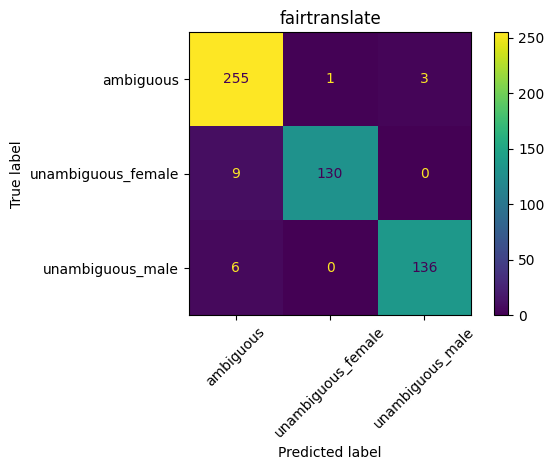

                    precision    recall  f1-score   support

         ambiguous      0.488     0.667     0.563        60
unambiguous_female      1.000     0.777     0.874        94
  unambiguous_male      0.770     0.761     0.766        88

          accuracy                          0.744       242
         macro avg      0.753     0.735     0.734       242
      weighted avg      0.789     0.744     0.758       242



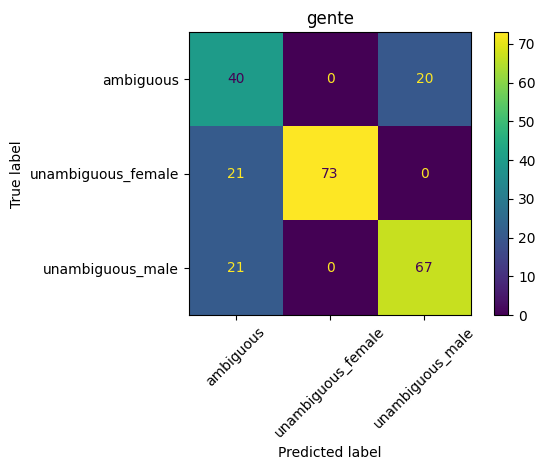

                    precision    recall  f1-score   support

         ambiguous      0.597     0.946     0.732       205
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.816     0.392     0.530        79
  unambiguous_male      0.917     0.289     0.440        76

          accuracy                          0.630       392
         macro avg      0.582     0.407     0.425       392
      weighted avg      0.654     0.630     0.575       392



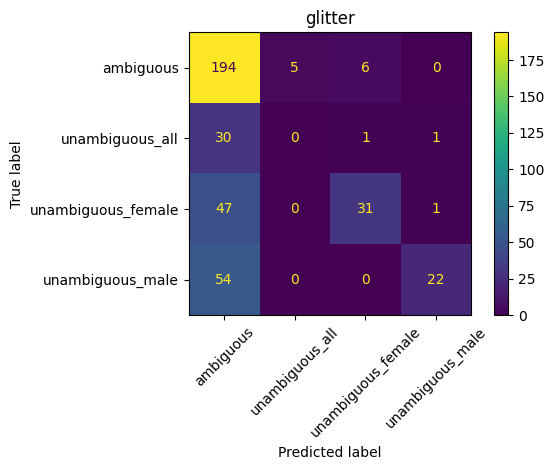

                    precision    recall  f1-score   support

         ambiguous      0.841     1.000     0.914       127
unambiguous_female      1.000     0.974     0.987       152
  unambiguous_male      0.992     0.852     0.917       142

          accuracy                          0.941       421
         macro avg      0.944     0.942     0.939       421
      weighted avg      0.949     0.941     0.941       421



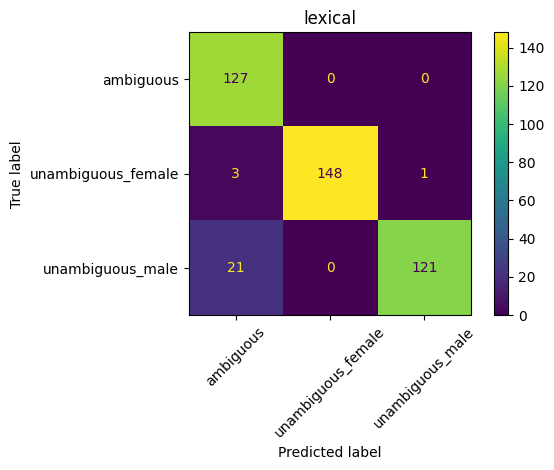

overall
                    precision    recall  f1-score   support

         ambiguous      0.744     0.946     0.833       651
   unambiguous_all      0.000     0.000     0.000        32
unambiguous_female      0.979     0.823     0.895       464
  unambiguous_male      0.930     0.772     0.844       448

          accuracy                          0.843      1595
         macro avg      0.663     0.635     0.643      1595
      weighted avg      0.850     0.843     0.837      1595



In [18]:
evaluate_test_rule(
    '../../data/full_test.tsv',
    'full-rule-results.tsv'
)